# XGBoost regression

**Target:** `log_time = log(Time_Delta_sec)`  
**Features:**  
- `log_distance`, `log_weight`, `log_cube`, `log_quantity`  
- `Aisle_group`, `Level_group`, `time_of_day`...


In [137]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    r2_score
)

import importlib
import feature_engineer

importlib.reload(feature_engineer)

<module 'feature_engineer' from '/Users/jiashenwang/Desktop/Lucas_Systems_Capstone_Project/Model_Jiashen/feature_engineer.py'>

In [138]:
from feature_engineer import get_engineered_df

DATA_PATH = "../data/processed/oe_detailed.parquet"
WAREHOUSE = "OE"
MAX_TIME = 300
WC = "30"

df, features, cat_cols = get_engineered_df(DATA_PATH, WAREHOUSE, MAX_TIME, WC)

print(f"Data shape: {df.shape}")
print(f"Number of days: {df['Timestamp'].dt.date.nunique()}")
print(f"Features: {features}")
print(f"Categorical columns: {cat_cols}")
df.head()

Data shape: (65298, 43)
Number of days: 8
Features: ['Travel_Distance', 'Weight', 'Cube', 'Quantity', 'Aisle_group', 'Level_group', 'time_of_day', 'same_aisle', 'same_lockey', 'diff_level', 'UOM_group', 'day_of_week', 'top_100_product', 'efficient_user']
Categorical columns: ['Aisle_group', 'Level_group', 'time_of_day', 'same_aisle', 'same_lockey', 'diff_level', 'UOM_group', 'day_of_week', 'top_100_product', 'efficient_user']


,ActivityCode,UserID,WorkCode,AssignmentID,ProductID,Quantity,Timestamp,LocationID,Prev_Timestamp,Prev_LocationID,...,time_of_day,UOM_group,day_of_week,same_aisle,same_lockey,diff_level,top_100_product,mean,count,efficient_user
0,PickPut,143,30,7717860,460,50,2025-09-08 12:12:18.127,422,2025-09-08 12:11:50.830,35192,...,12-4,EA,Monday,1,0,0,0,0.243243,0.837838,0
1,PickPut,143,30,7717908,460,100,2025-09-08 12:15:46.650,422,2025-09-08 12:12:18.127,422,...,12-4,EA,Monday,1,1,0,0,0.243243,0.837838,0
2,PickPut,143,30,7717921,44547,13,2025-09-08 12:16:30.470,10743,2025-09-08 12:15:46.650,422,...,12-4,EA,Monday,1,1,0,0,0.243243,0.837838,0
3,PickPut,143,30,7717920,44547,13,2025-09-08 12:18:00.970,10743,2025-09-08 12:16:30.470,10743,...,12-4,EA,Monday,1,1,0,0,0.243243,0.837838,0
4,PickPut,143,30,7717815,191,8,2025-09-08 12:18:45.173,2985,2025-09-08 12:18:00.970,10743,...,12-4,BX,Monday,1,0,0,0,0.243243,0.837838,0


In [139]:
# Split into train/test (same 80/20 random split)
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (52238, 43)
Test shape: (13060, 43)


In [140]:
# ---------- Build design matrix ----------
def build_X(df_in: pd.DataFrame) -> pd.DataFrame:
    X = df_in[features].copy()
    X = pd.get_dummies(X, columns=cat_cols, drop_first=True)
    X = X.replace([np.inf, -np.inf], np.nan).fillna(0)
    return X.astype(float)

X_train = build_X(train_df)
X_test  = build_X(test_df)

# Align columns (important with one-hot)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

y_train = train_df["Time_Delta_sec"].astype(float).values
y_test  = test_df["Time_Delta_sec"].astype(float).values

print("X_train:", X_train.shape, "X_test:", X_test.shape)

X_train: (52238, 29) X_test: (13060, 29)


In [141]:
display(X_train.head())

,Travel_Distance,Weight,Cube,Quantity,Aisle_group_40,Aisle_group_41,Aisle_group_42,Aisle_group_other,Level_group_2,Level_group_3,...,UOM_group_CA,UOM_group_CS,UOM_group_EA,UOM_group_PK,UOM_group_other,day_of_week_Thursday,day_of_week_Tuesday,day_of_week_Wednesday,top_100_product_1,efficient_user_1
42271,0.0,0.2095,0.043,5.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
63790,0.0,0.1167,0.016,6.0,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
45332,0.0,0.0750,0.003,2.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
64546,16.0,0.0100,0.037,4.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25349,0.0,0.2500,0.085,20.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


In [142]:
# ---------- XGBoost model (simple sklearn fit; no early stopping) ----------

from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

xgb = XGBRegressor(
    n_estimators=2000,          # keep reasonable since no early stopping
    learning_rate=0.03,
    max_depth=6,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.0,
    reg_lambda=1.0,
    objective="reg:gamma",
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_tr, y_tr)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=3, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=2000,
             n_jobs=-1, num_parallel_tree=None, ...)

In [143]:
# ---------- Evaluation ----------
pred = xgb.predict(X_test)

# Metrics
r2   = r2_score(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
mae  = mean_absolute_error(y_test, pred)

print("=== Test metrics===")
# Print warehouse name and workcode for clarity
print(f"{WAREHOUSE}, WorkCode {WC}, Max {MAX_TIME}s")
# print training set rows
print(f"Train rows: {len(X_train)}")
print(f"R^2   : {r2:.4f}")
print(f"MAE   : {mae:.4f}")

#print(f"RMSE  : {rmse:.4f}")

=== Test metrics===
OE, WorkCode 30, Max 300s
Train rows: 52238
R^2   : 0.3824
MAE   : 21.8082


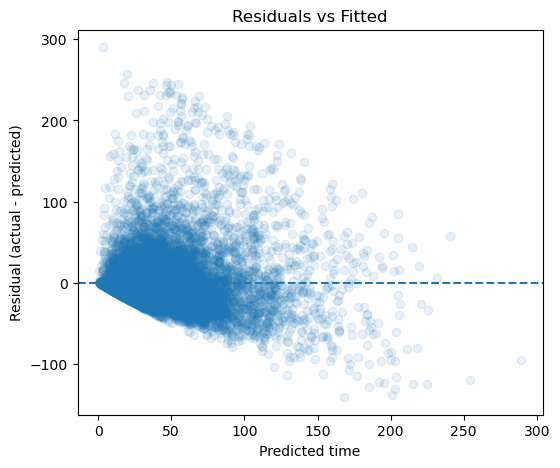

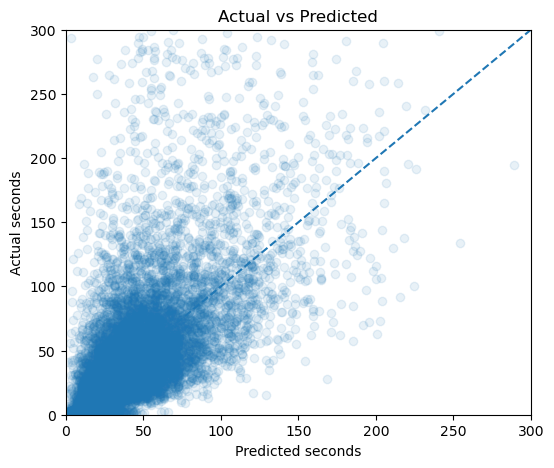

In [144]:
# ---------- Diagnostics plots ----------
resid = y_test - pred

# Residual vs fitted
plt.figure(figsize=(6,5))
plt.scatter(pred, resid, alpha=0.1)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted time")
plt.ylabel("Residual (actual - predicted)")
plt.title("Residuals vs Fitted")
plt.show()

# Actual vs predicted
lims = [0, 300]
plt.figure(figsize=(6,5))
plt.scatter(pred, y_test, alpha=0.1)
plt.xlim(lims)
plt.ylim(lims)
plt.plot(lims, lims, "--")
plt.xlabel("Predicted seconds")
plt.ylabel("Actual seconds")
plt.title("Actual vs Predicted")
plt.show()


,feature,importance
17,same_lockey_1,0.158221
18,diff_level_1,0.138677
16,same_aisle_1,0.089549
0,Travel_Distance,0.075265
7,Aisle_group_other,0.042103
3,Quantity,0.041822
27,top_100_product_1,0.040322
2,Cube,0.027899
22,UOM_group_PK,0.026755
4,Aisle_group_40,0.024874


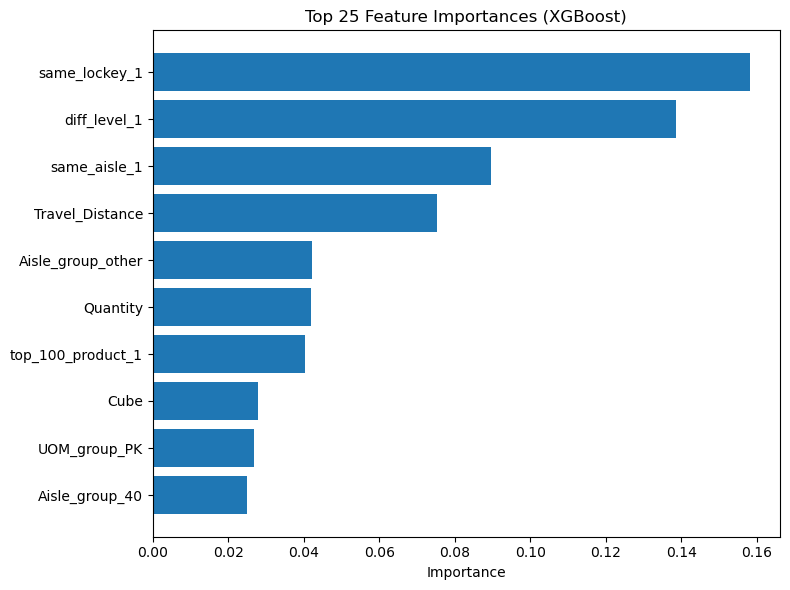

In [147]:
# ---------- Feature importance ----------
# Gain-based importance
importances = xgb.feature_importances_
imp = (
    pd.DataFrame({"feature": X_train.columns, "importance": importances})
    .sort_values("importance", ascending=False)
)

display(imp.head(25))

plt.figure(figsize=(8,6))
plt.barh(imp.head(10)["feature"][::-1], imp.head(10)["importance"][::-1])
plt.title("Top 25 Feature Importances (XGBoost)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()